<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>K Nearest Neighbour - KNN </h2>
</div>

- Based on i/p data's neighbours characterstic, understanding input data.
- Supervised Classification/Regression algorithm
- It can be used for both classification and regression problems. 
- However, it is more widely used in classification problems in the industry. 
- K nearest neighbors is a simple algorithm that stores all available cases and classifies new cases by a majority vote of its k neighbors.
- The case being assigned to the class is most common amongst its K nearest neighbors measured by a distance function.
- These distance functions can be Euclidean, Manhattan, Minkowski and Hamming distance.
- First three functions are used for continuous function and the fourth one (Hamming) for categorical variables.
- If K = 1, then the case is simply assigned to the class of its nearest neighbor. At times, choosing K turns out to be a challenge while performing kNN modeling.

- In KNN, we  fit the model With different K value  and plot accuracy (Y -axis) vs no of K value and  draw the graph. where accuracy is good, that k value will be considered as final k value

- But In K mean Cluster, we  fit the model With different K value,  we draw Elbow method graph(Another way Dendogram). i.e distortion(Within Cluster Sum of Square error WCSS) as Y-axis  and no of cluster(K) as X axis. Where Distortion drops suddenly that point considered as best cluster no or K, that k value will be considered as final k value





- KNN is computationally expensive
- Variables should be normalized else higher range variables can bias it
- Works on pre-processing stage more before going for kNN like an outlier, noise removal




- In Normal Classification Problem we wont draw 2 D graph coz input is more than 1 column. That time we do like normal way, all input col as X and output as Y and fit the model with KNN algorith and validate model with accuracy, classification report, confusion matrix, ROC etc
- In Some Classification graph, both axis X and  axis Y will be features/input variable, legend will be tells scatter object belongs to which class. (This looks like Cluster only)
- In Regression graph, X will be i/p and Y will be O/P, No legend here, its not classification/Grouping. Its continous value



- Literature says if k is small, model is complex model can lead to overfit. It means that model memorizes the train sets and cannot predict test set with good accuracy.
- If k is big, model that is less complex model can lead to underfit.


> Points to Consider in KNN	
	
    - 1. define what distance( Euclidean, Manhoutan, Minkowski, Hamming distance)
	
	- 2. how many of these nearest neighbors (Define K value). We manually need to set proper K value
	
	- 3. Optional weighting points on the neighbour points 
            Third, we may want to give some neighbors more influence on the outcome. For example, we may decide that neighbors that are closer to the new instance that we're trying to classify, should have more influence, or more votes on the final label.

	
	- 4. How to aggregate the classes on neighbour points



<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>


- We have run_or_walk value of pedometer device, we need to predict based on the existing data

- activity is the output field 0 means walk 1 means Run

##  1. Import all Librariy

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns

from sklearn.model_selection import train_test_split


runorwalk = pd.read_csv(r"..\Dataset\run_or_walk.csv")
runorwalk.head()

,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,2017-6-30,13:51:15:847724020,viktor,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,2017-6-30,13:51:16:246945023,viktor,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,2017-6-30,13:51:16:446233987,viktor,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,2017-6-30,13:51:16:646117985,viktor,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,2017-6-30,13:51:16:846738994,viktor,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922


## 2. Data Exploration with Graphs and Visualization


In [15]:
##Dat wrangling
#Chcke Null in dataset, no null found
runorwalk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88588 entries, 0 to 88587
Data columns (total 11 columns):
date              88588 non-null object
time              88588 non-null object
username          88588 non-null object
wrist             88588 non-null int64
activity          88588 non-null int64
acceleration_x    88588 non-null float64
acceleration_y    88588 non-null float64
acceleration_z    88588 non-null float64
gyro_x            88588 non-null float64
gyro_y            88588 non-null float64
gyro_z            88588 non-null float64
dtypes: float64(6), int64(2), object(3)
memory usage: 7.4+ MB


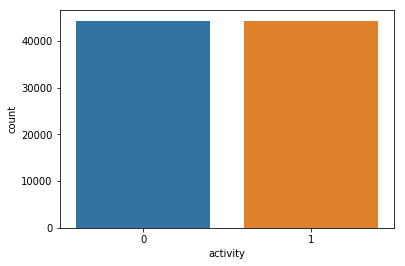

In [16]:
sns.countplot(runorwalk.activity)

## 3. Building Machine Learning KNN Models

In [17]:
from sklearn.neighbors import KNeighborsClassifier
# train test split
from sklearn.model_selection import train_test_split

x = runorwalk.loc[:,:]
x = x.drop(["activity","date", "time","username","wrist"], axis=1)
y = runorwalk.loc[:,["activity"]]
y[:5]


x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3,random_state = 1)


## 3.1  How to choose hyperparameter (K) value

#### At below, I range K value from 1 to 25(exclude) and find accuracy for each K value. As you can see in plot, when K is 1 it memozize train sets and cannot give good accuracy on test set (overfit). Also if K is 18, model is lead to underfit. Again accuracy is not enough. However look at when K is 18(best performance), accuracy has highest value almost 88%.

##### This is sample program, it will give graph- y axis(Accuracy) vs (Number of Neighbours(k)) by this we can find which is the best K value 

C:\Users\prabh\Anaconda3\lib\site-packages\ipykernel_launcher.py:10: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  # Remove the CWD from sys.path while we load stuff.
C:\Users\prabh\Anaconda3\lib\site-packages\ipykernel_launcher.py:10: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  # Remove the CWD from sys.path while we load stuff.
C:\Users\prabh\Anaconda3\lib\site-packages\ipykernel_launcher.py:10: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  # Remove the CWD from sys.path while we load stuff.
C:\Users\prabh\Anaconda3\lib\site-packages\ipykernel_launcher.py:10: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please chang

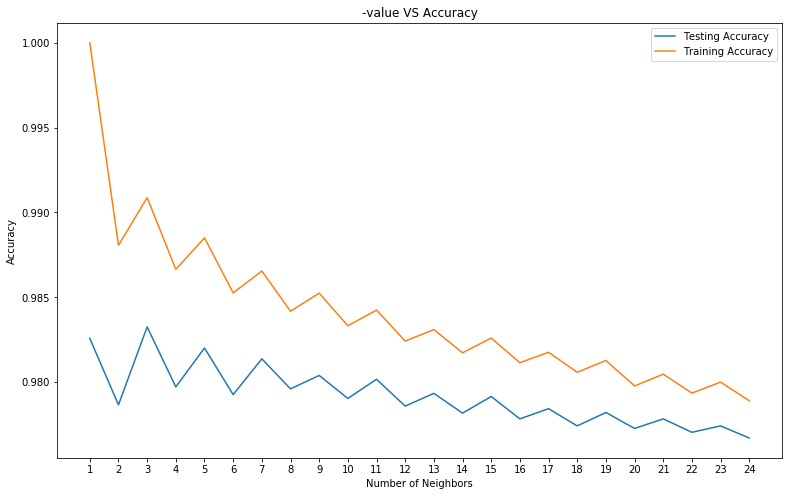

Best accuracy is 0.9832561989690334 with K = 3


In [18]:
# Model complexity
neig = np.arange(1, 25)
train_accuracy = []
test_accuracy = []
# Loop over different values of k
for i, k in enumerate(neig):
    # k from 1 to 25(exclude)
    knn = KNeighborsClassifier(n_neighbors=k)
    # Fit with knn
    knn.fit(x_train,y_train)
    #train accuracy
    train_accuracy.append(knn.score(x_train, y_train))
    # test accuracy
    test_accuracy.append(knn.score(x_test, y_test))

# Plot
plt.figure(figsize=[13,8])
plt.plot(neig, test_accuracy, label = 'Testing Accuracy')
plt.plot(neig, train_accuracy, label = 'Training Accuracy')
plt.legend()
plt.title('-value VS Accuracy')
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.xticks(neig)
plt.savefig('graph.png')
plt.show()

# Here it gives best K value with max accuracy for test data
print("Best accuracy is {} with K = {}"
      .format(np.max(test_accuracy),1+test_accuracy.index(np.max(test_accuracy))))

In [19]:
# Here we are setting No of K as 3 which has best accuracy
knn = KNeighborsClassifier(n_neighbors = 3)
#x,y = data.loc[:,data.columns != 'class'], data.loc[:,'class']

knn.fit(x_train,y_train)
prediction = knn.predict(x_test)
#print('Prediction: {}'.format(prediction))
print('With KNN (K=3) accuracy is: ',knn.score(x_test,y_test)) # accuracy

C:\Users\prabh\Anaconda3\lib\site-packages\ipykernel_launcher.py:5: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  """


With KNN (K=3) accuracy is:  0.9832561989690334


## 4. Model Evaluation

### 4.1 Model Evaluation - Accuracy Score

In [20]:
print("KNN Classifier Accuracy: " ,metrics.accuracy_score(y_test, prediction))

KNN Classifier Accuracy:  0.9832561989690334


### 4.2. Model Evaluation - confusion_matrix  

In [21]:
#confusion_matrix 
from sklearn.metrics import confusion_matrix


print("\n Confusion_matrix: \n" ,confusion_matrix(y_test, prediction , labels =[0,1]))


 Confusion_matrix: 
 [[13079    90]
 [  355 13053]]


(Text(83.40000000000006, 0.5, 'Predicted'),)

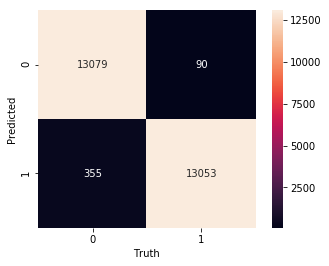

In [22]:
import matplotlib.pyplot as plt

mat = confusion_matrix(y_test, prediction)
sns.heatmap(mat,
            fmt='d',
            square=True,
            cbar=True,
            annot=True,
            xticklabels=[0,1],
            yticklabels=[0,1]) # This should be distinct classes

# Same can be done for all 3
plt.xlabel('Truth'),
plt.ylabel('Predicted'),

### 4.3. Model Evaluation - classification_report  

In [23]:
    #Classification Report AND confusion matrix

    from sklearn.metrics import classification_report


    target_names = ["Walk","Run"]
    print("Classification_report: \n" ,classification_report(y_test, prediction, target_names=target_names))


Classification_report: 
               precision    recall  f1-score   support

        Walk       0.97      0.99      0.98     13169
         Run       0.99      0.97      0.98     13408

   micro avg       0.98      0.98      0.98     26577
   macro avg       0.98      0.98      0.98     26577
weighted avg       0.98      0.98      0.98     26577



### 4.4. Model Evaluation - ROC  

[1. 0. 0. 1. 1.]
Area under curve with 3 KNN 0.9926868417566314


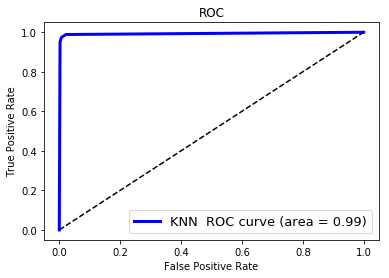

In [24]:
#ROC Curve with AUC
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

#Predictor_score LOG REG
y_pred_prob = knn.predict_proba(x_test)[:,1]
print(y_pred_prob[0:5])



# ROC curve Log Reg
fpr_LogR, tpr_LogR, thresholds_LogR = roc_curve(y_test, y_pred_prob)

roc_auc_logR = auc(fpr_LogR, tpr_LogR)
print("Area under curve with 3 KNN %s" %roc_auc_logR)




# Plot ROC Diagnol curve
plt.plot([0, 1], [0, 1], 'k--')

#plt.plot(fpr, tpr)  # X axis false +ve rate, Y axis True +ve rate

# Or with AUC
plt.plot(fpr_LogR, tpr_LogR, color = 'b', lw=3, label='KNN  ROC curve (area = {:0.2f})'.format(roc_auc_logR))

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', fontsize=13)
plt.title('ROC')
plt.show()

## 5. CONCLUSION

- Model gives very good accuracy and good AUC